# Лабораторная работа 1

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./AmesHousing.txt', sep = '\t')
# Число столбцов
len(df.columns)

82

In [4]:
# Список числовых столцов
numeric_cols = df.drop(columns = ['SalePrice', 'Order']).describe(include = [np.number]).columns
numeric_cols

Index(['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold'],
      dtype='object')

In [5]:
# есть ли пропуски в цене
df['SalePrice'].isna().sum()

0

## Выбор переменных

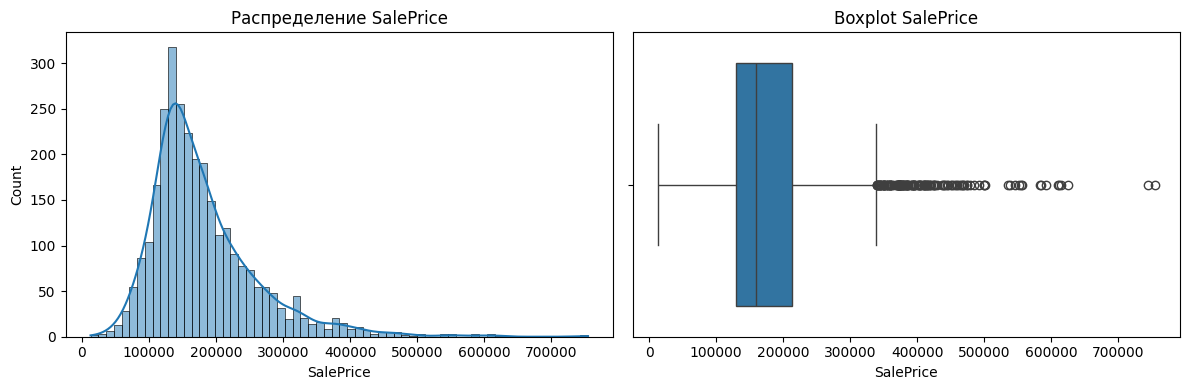

Коэффициент асимметрии: 1.74


In [6]:
plt.figure(figsize=(12, 4))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('Распределение SalePrice')

# Ящик с усами для цен
plt.subplot(1, 2, 2)
sns.boxplot(x = df['SalePrice'])
plt.title('Boxplot SalePrice')

plt.tight_layout()
plt.show()

print(f"Коэффициент асимметрии: {df['SalePrice'].skew():.2f}")

### Вывод:

Так как распределение `SalePrice` заметно асимметрично (коэффициент асимметрии > 1), выбираем непараметрическую проверку различия **медиан** (а не средних).

Гипотезы:
- $H_0$: медианы `SalePrice` в двух группах равны.
- $H_1$: медианы `SalePrice` в двух группах различаются.

В качестве признаков выбраны:
- **Year Built** (год постройки)
- **Yr Sold** (год продажи)

## Проверка гипотез

Переменная: Year Built
Медиана группы (< медианы): 132125.00
Медиана группы (>= медианы): 202582.50
Вывод: Медианы цен статистически значимо различаются
   (p-value = 4.7103028804930785e-261 < 0.05)


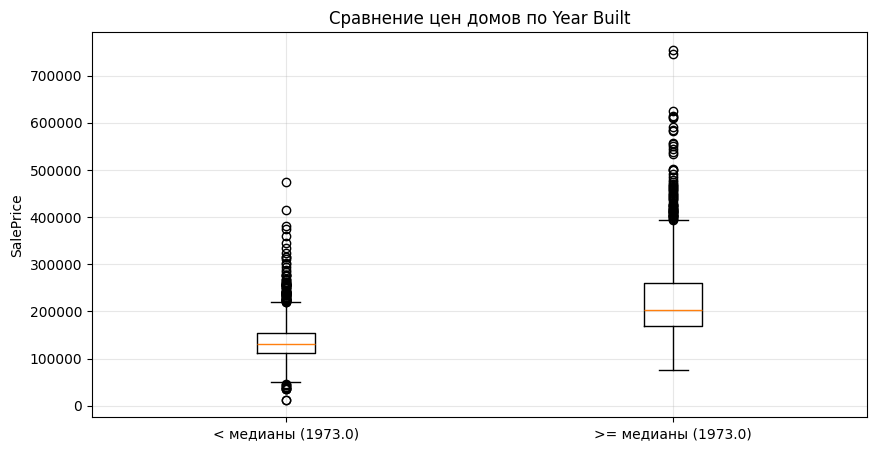

Переменная: Yr Sold
Медиана группы (< медианы): 162500.00
Медиана группы (>= медианы): 160000.00
Вывод: Нет оснований считать, что медианы различаются
   (p-value = 0.2261649462418669 >= 0.05)


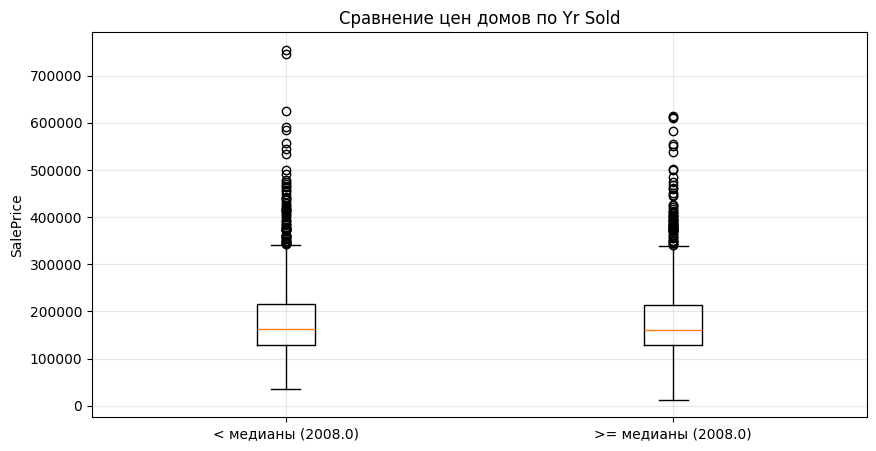

In [45]:
def compare_prices(column):
    # разделение столбца по медиане
	median = df[column].median()
	df_less = df[df[column] < median]['SalePrice']
	df_more = df[df[column] >= median]['SalePrice']

	# тест Манна-Уитни (для сравнения медиан)
	stat, p_value = stats.mannwhitneyu(df_more, df_less, alternative = 'two-sided')
	print(f"Переменная: {column}")
	print(f"Медиана группы (< медианы): {df_less.median():.2f}")
	print(f"Медиана группы (>= медианы): {df_more.median():.2f}")

	alpha = 0.05
	if p_value < alpha:
		print("Вывод: Медианы цен статистически значимо различаются")
		print(f"   (p-value = {p_value} < {alpha})")
	else:
		print("Вывод: Нет оснований считать, что медианы различаются")
		print(f"   (p-value = {p_value} >= {alpha})")

	# визуализация
	plt.figure(figsize = (10, 5))
	data_to_plot = [df_less, df_more]
	plt.boxplot(data_to_plot, tick_labels=[f'< медианы ({median})', f'>= медианы ({median})'])
	plt.title(f'Сравнение цен домов по {column}')
	plt.ylabel('SalePrice')
	plt.grid(True, alpha=0.3)
	plt.show()

compare_prices('Year Built')
compare_prices('Yr Sold')

### Вывод:

Интерпретация результатов теста Манна—Уитни при уровне значимости $\alpha = 0.05$:

- **Year Built**: $p$-value < $\alpha$ ⇒ отвергаем $H_0$; медианы `SalePrice` в группах различаются. По boxplot видно, что в группе с **более новым** жильём (Year Built $\ge$ медианы) медианная цена выше.
- **Yr Sold**: $p$-value $\ge \alpha$ ⇒ нет оснований отвергать $H_0$; статистически значимых различий медиан `SalePrice` между группами не обнаружено.